In [15]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import unittest

tc = unittest.TestCase()

sns.set_theme(style="ticks")
sns.set_context("poster", font_scale=2)
sns.set_palette("Set1", 10)
sns.set_style({"font.family": "serif", "font.serif": "Courier New"})

if Path.cwd().name == "workdir":
    pass
elif Path.cwd().name == "proj-jailbreak-sandbox":
    os.chdir("workdir")
elif Path.cwd().name == "core":
    os.chdir("../../workdir")
else:
    print(Path.cwd())
    print(
        "Current directory is not workdir or proj-jailbreak-sandbox. Please check the path."
    )
    exit(1)

print(Path.cwd())
figure_dir_path = Path(
    r"/scratch/gilbreth/hongyu/project/sandbox/2024-Defend-Transferable-Jailbreak-with-Speculative-Inference/figures"
)

/scratch/gilbreth/hongyu/project/sandbox/proj-jailbreak-sandbox/workdir


In [7]:
dataset_name = "RPAB"
intent_number = 50

target_model_name_list = [
    "Meta-Llama-3-70B-Instruct-AWQ",
    "Qwen1.5-72B-Chat-AWQ",
    "Phi-3-medium-128k-instruct",
]
generation_name_list = ["GCG", "AutoDAN"]
dataset_name_list = ["RPAB"]
draft_model_name_list = [
    "opt-125m-AWQ",
    "SmolLM-135M",
    "Qwen2.5-0.5B",
    "Llama-3.2-1B",
    "SmolLM2-135M",
    "SmolLM2-360M",
]
# draft_number_list = [5, 10, 15, 20, 25, 30, 35]
draft_number_list = [20]

In [4]:
a = sns.load_dataset("glue")

In [5]:
b = a.pivot(index="Model", columns="Task", values="Score")

In [28]:
def read_pickle(step_6_result_path, generation_name):
    with open(
        step_6_result_path,
        "rb",
    ) as f:
        step_6_pickle_data = pickle.load(f)
        attempts = step_6_pickle_data["attempts"]
        df = pd.DataFrame(attempts)
        df["attempt_id"] = df.index
        df = df.drop(columns=["prompt", "responses"])

        if generation_name == "GCG":
            assert len(df) == 100
        elif generation_name == "AutoDAN":
            assert len(df) == 50
        else:
            raise ValueError(f"generation_name {generation_name} is not supported.")

        return df

In [66]:
step_6_result_list = []

target_model_name_dict = {
    "Meta-Llama-3-70B-Instruct-AWQ": "Llama-3-70B",
    "Qwen1.5-72B-Chat-AWQ": "Qwen1.5-72B",
    "Phi-3-medium-128k-instruct": "Phi-3-medium",
}

for dataset_name in dataset_name_list:
    for target_model_name in target_model_name_list:
        for generation_name in generation_name_list:
            for draft_model_name in draft_model_name_list:
                for draft_number in draft_number_list:
                    for intent_index in range(intent_number):
                        step_6_result_path = (
                            Path().cwd()
                            / "step_6_result"
                            / dataset_name
                            / target_model_name
                            / generation_name
                            / draft_model_name
                            / f"{draft_number}"
                            / f"{intent_index}.pkl"
                        )
                        df = read_pickle(step_6_result_path, generation_name)

                        df["dataset_name"] = dataset_name
                        df["target_model_name"] = target_model_name_dict[target_model_name]
                        df["generation_name"] = generation_name
                        df["draft_model_name"] = draft_model_name
                        df["draft_number"] = draft_number
                        df["intent_index"] = intent_index

                        step_6_result_list.append(df)

df = pd.concat(step_6_result_list, ignore_index=True)
print(df.shape)


def generate_transferability_rate(row):
    assert len(row["labels"]) == row["draft_number"]
    transferability_rate = sum(row["labels"]) / row["draft_number"]
    return transferability_rate


df[f"transferability_rate"] = df.apply(generate_transferability_rate, axis=1)
df = df.drop(columns=["labels", "time"])

(135000, 9)


In [67]:
v = (
    len(dataset_name_list)
    * len(target_model_name_list)
    * len(draft_model_name_list)
    * len(draft_number_list)
    * intent_number
)*150

tc.assertEqual(len(df), v)

In [68]:
original_df = df
original_df.columns

Index(['attempt_id', 'dataset_name', 'target_model_name', 'generation_name',
       'draft_model_name', 'draft_number', 'intent_index',
       'transferability_rate'],
      dtype='object')

In [69]:
df = original_df

assert len(df["dataset_name"].unique()) == 1
assert len(df["draft_number"].unique()) == 1

df = original_df.drop(
    columns=[
        "dataset_name",
        "draft_number",
    ]
)

# filter the data from df, where the (generation_name=="GCG" and attempt_id==99) or (generation_name=="AutoDAN" and attempt_id==49)
df = df[
    ((df["generation_name"] == "GCG") & (df["attempt_id"] == 99))
    | ((df["generation_name"] == "AutoDAN") & (df["attempt_id"] == 49))
]

df_gcg = df[df["generation_name"] == "GCG"]
assert len(df_gcg["generation_name"].unique()) == 1
assert len(df_gcg["attempt_id"].unique()) == 1
df_gcg = df_gcg.drop(
    columns=[
        "generation_name",
        "attempt_id",
    ]
)

df_autodan = df[df["generation_name"] == "AutoDAN"]
assert len(df_autodan["generation_name"].unique()) == 1
assert len(df_autodan["attempt_id"].unique()) == 1
df_autodan = df_autodan.drop(
    columns=[
        "generation_name",
        "attempt_id",
    ]
)

In [70]:
def agg_intent_index(df):
    v = df.groupby(["target_model_name", "draft_model_name"])[
        "transferability_rate"
    ].agg(["mean", "max", "std"]).reset_index()
    return v

In [71]:
df_gcg_agg = agg_intent_index(df_gcg)
df_autodan_agg = agg_intent_index(df_autodan)

In [72]:
df_gcg_agg

,target_model_name,draft_model_name,mean,max,std
0,Llama-3-70B,Llama-3.2-1B,0.122,0.50,0.142198
1,Llama-3-70B,Qwen2.5-0.5B,0.337,0.85,0.229420
2,Llama-3-70B,SmolLM-135M,0.713,1.00,0.265885
3,Llama-3-70B,SmolLM2-135M,0.079,0.40,0.089266
4,Llama-3-70B,SmolLM2-360M,0.103,0.35,0.101222
5,Llama-3-70B,opt-125m-AWQ,0.602,1.00,0.257729
6,Phi-3-medium,Llama-3.2-1B,0.113,0.95,0.165310
7,Phi-3-medium,Qwen2.5-0.5B,0.390,0.90,0.265922
8,Phi-3-medium,SmolLM-135M,0.419,0.90,0.284083
9,Phi-3-medium,SmolLM2-135M,0.096,0.35,0.088548


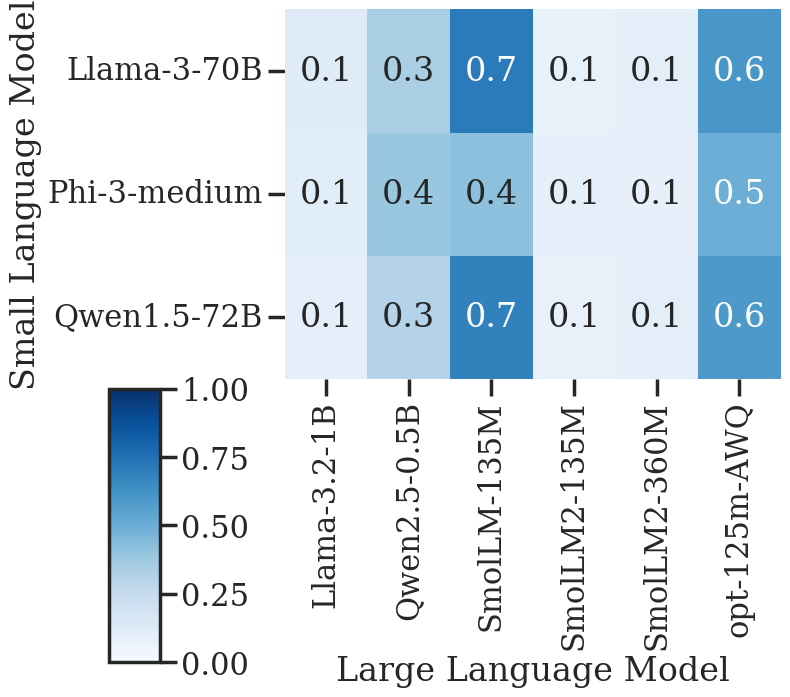

In [106]:
df_pivot = df_gcg_agg.pivot(
    index="target_model_name", columns="draft_model_name", values="mean"
)
sns.heatmap(df_pivot, annot=True, fmt=".1f", vmin=0, vmax=1, cmap="Blues", cbar=False)

# change the x-axis label to "Draft Model"
plt.xlabel("Large Language Model")
plt.ylabel("Small Language Model")

cbar_ax = plt.axes([-0.15, -0.48, 0.08, 0.57])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)

plt.show()